### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
#Calcular suma de ingresos por cada tienda

ingresos_tienda = tienda['Precio'].sum()
ingresos_tienda2 = tienda2['Precio'].sum()
ingresos_tienda3 = tienda3['Precio'].sum()
ingresos_tienda4 = tienda4['Precio'].sum()

#Organizar los datos en listas para graficar

tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = [ingresos_tienda, ingresos_tienda2, ingresos_tienda3, ingresos_tienda4]

print(ingresos_tienda)


1150880400.0


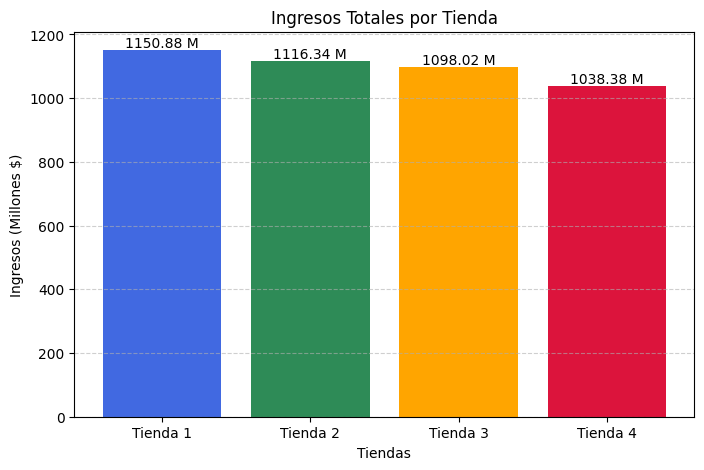

In [4]:
import matplotlib.pyplot as plt

tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos_millones = [i/1000000 for i in ingresos]

colores = ['royalblue', 'seagreen', 'orange', 'crimson']

plt.figure(figsize=(8,5))

barras = plt.bar(tiendas, ingresos_millones, color=colores)

plt.title('Ingresos Totales por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Ingresos (Millones $)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Agregar data labels en millones
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2,
             altura,
             f'{altura:.2f} M',
             ha='center',
             va='bottom')

plt.show()

# 2. Ventas por categoría

In [5]:
ventas_categoria_t1 = tienda['Categoría del Producto'].value_counts()
ventas_categoria_t2 = tienda2['Categoría del Producto'].value_counts()
ventas_categoria_t3 = tienda3['Categoría del Producto'].value_counts()
ventas_categoria_t4 = tienda4['Categoría del Producto'].value_counts()

print("Ventas por categoría - Tienda 1")
print(ventas_categoria_t1)

print("\nVentas por categoría - Tienda 2")
print(ventas_categoria_t2)

print("\nVentas por categoría - Tienda 3")
print(ventas_categoria_t3)

print("\nVentas por categoría - Tienda 4")
print(ventas_categoria_t4)

Ventas por categoría - Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Ventas por categoría - Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Ventas por categoría - Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Ventas por

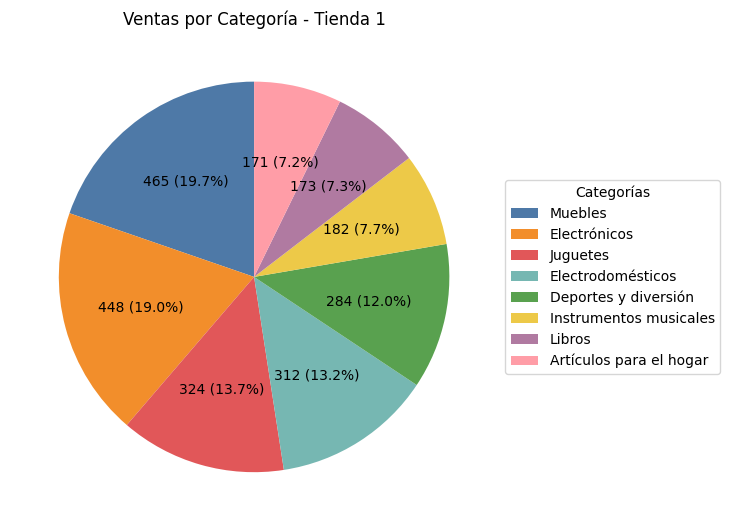

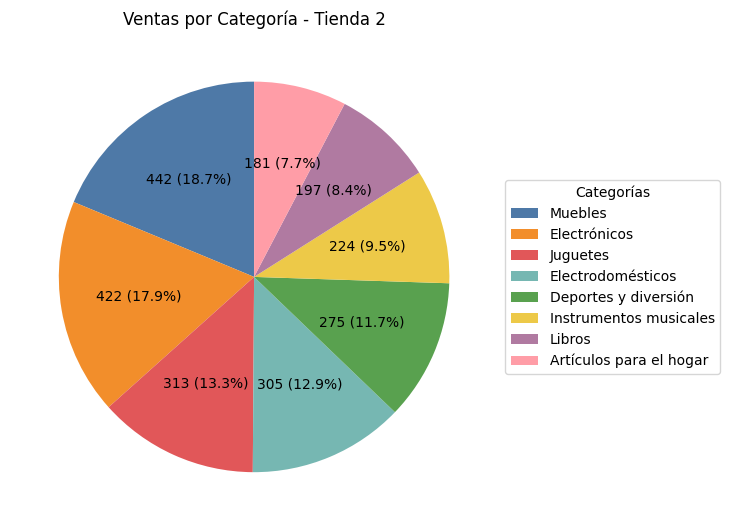

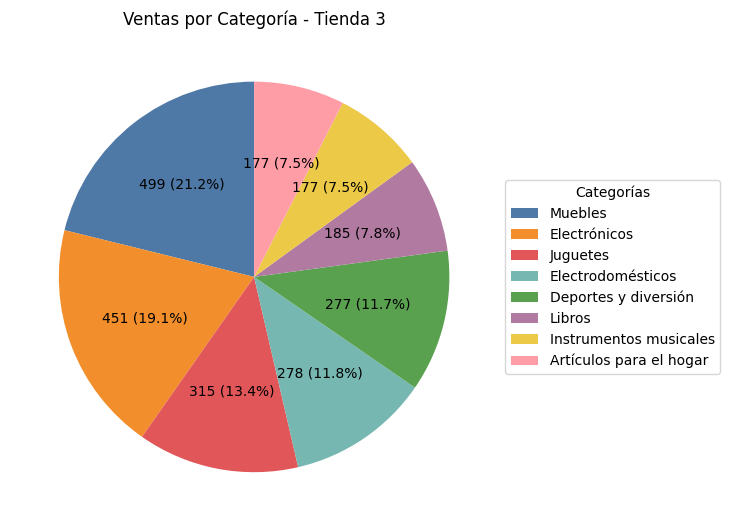

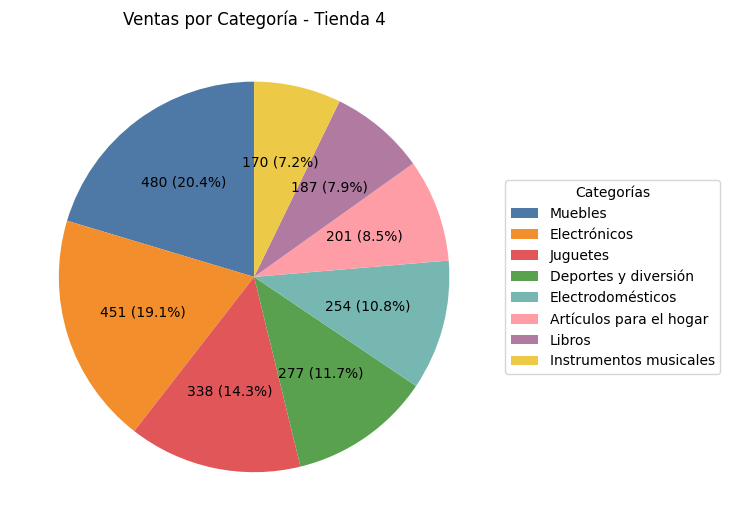

In [6]:
import matplotlib.pyplot as plt

def formato_autopct(valores):
    def mi_autopct(pct):
        total = sum(valores)
        valor = int(round(pct * total / 100.0))
        return f'{valor} ({pct:.1f}%)'
    return mi_autopct


tiendas = {
    "Tienda 1": ventas_categoria_t1,
    "Tienda 2": ventas_categoria_t2,
    "Tienda 3": ventas_categoria_t3,
    "Tienda 4": ventas_categoria_t4
}

colores_categorias = {
    'Muebles': '#4E79A7',
    'Electrónicos': '#F28E2B',
    'Juguetes': '#E15759',
    'Electrodomésticos': '#76B7B2',
    'Deportes y diversión': '#59A14F',
    'Instrumentos musicales': '#EDC948',
    'Libros': '#B07AA1',
    'Artículos para el hogar': '#FF9DA7'
}

for nombre, datos in tiendas.items():

    valores = datos.values
    labels = datos.index
    colores = [colores_categorias[c] for c in labels]

    plt.figure(figsize=(7,6))

    wedges, texts, autotexts = plt.pie(
        valores,
        colors=colores,
        autopct=formato_autopct(valores),
        startangle=90
    )

    plt.title(f'Ventas por Categoría - {nombre}')

    plt.legend(
        wedges,
        labels,
        title="Categorías",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()

    plt.show()

# 3. Calificación promedio de la tienda


In [13]:
calificacion_t1 = tienda['Calificación'].mean()
calificacion_t2 = tienda2['Calificación'].mean()
calificacion_t3 = tienda3['Calificación'].mean()
calificacion_t4 = tienda4['Calificación'].mean()

print("La calificación promedio Tienda 1:", round(calificacion_t1,2))
print("La calificación promedio Tienda 2:", round(calificacion_t2,2))
print("La calificación promedio Tienda 3:", round(calificacion_t3,2))
print("La calificación promedio Tienda 4:", round(calificacion_t4,2))

datos_calificaciones = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificación Promedio': [calificacion_t1, calificacion_t2, calificacion_t3, calificacion_t4]
})

datos_calificaciones = datos_calificaciones.sort_values(by='Calificación Promedio')

La calificación promedio Tienda 1: 3.98
La calificación promedio Tienda 2: 4.04
La calificación promedio Tienda 3: 4.05
La calificación promedio Tienda 4: 4.0


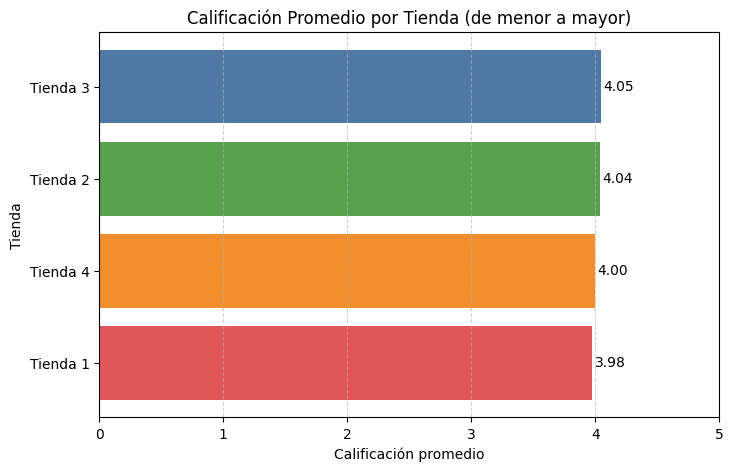

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

barras = plt.barh(datos_calificaciones['Tienda'],
                  datos_calificaciones['Calificación Promedio'],
                  color=['#E15759','#F28E2B','#59A14F','#4E79A7'])

plt.title('Calificación Promedio por Tienda (de menor a mayor)')
plt.xlabel('Calificación promedio')
plt.ylabel('Tienda')
plt.xlim(0,5)

# Etiquetas de valor
for barra in barras:
    ancho = barra.get_width()
    plt.text(ancho + 0.02,
             barra.get_y() + barra.get_height()/2,
             f'{ancho:.2f}',
             va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# 4. Productos más y menos vendidos

In [12]:
ventas_producto_t1 = tienda['Producto'].value_counts()
ventas_producto_t2 = tienda2['Producto'].value_counts()
ventas_producto_t3 = tienda3['Producto'].value_counts()
ventas_producto_t4 = tienda4['Producto'].value_counts()

mas_vendido_t1 = ventas_producto_t1.idxmax()
mas_vendido_t2 = ventas_producto_t2.idxmax()
mas_vendido_t3 = ventas_producto_t3.idxmax()
mas_vendido_t4 = ventas_producto_t4.idxmax()

menos_vendido_t1 = ventas_producto_t1.idxmin()
menos_vendido_t2 = ventas_producto_t2.idxmin()
menos_vendido_t3 = ventas_producto_t3.idxmin()
menos_vendido_t4 = ventas_producto_t4.idxmin()

print("Para la tienda 1 el producto más vendido es", mas_vendido_t1,
      "con", ventas_producto_t1.max(),
      "productos vendidos, mientras que el menos vendido es", menos_vendido_t1,
      "con tan solo", ventas_producto_t1.min(), "productos vendidos")

print("Para la tienda 2 el producto más vendido es", mas_vendido_t2,
      "con", ventas_producto_t2.max(),
      "productos vendidos, mientras que el menos vendido es", menos_vendido_t2,
      "con tan solo", ventas_producto_t2.min(), "productos vendidos")

print("Para la tienda 3 el producto más vendido es", mas_vendido_t3,
      "con", ventas_producto_t3.max(),
      "productos vendidos, mientras que el menos vendido es", menos_vendido_t3,
      "con tan solo", ventas_producto_t3.min(), "productos vendidos")

print("Para la tienda 4 el producto más vendido es", mas_vendido_t4,
      "con", ventas_producto_t4.max(),
      "productos vendidos, mientras que el menos vendido es", menos_vendido_t4,
      "con tan solo", ventas_producto_t4.min(), "productos vendidos")

Para la tienda 1 el producto más vendido es Microondas con 60 productos vendidos, mientras que el menos vendido es Auriculares con micrófono con tan solo 33 productos vendidos
Para la tienda 2 el producto más vendido es Iniciando en programación con 65 productos vendidos, mientras que el menos vendido es Juego de mesa con tan solo 32 productos vendidos
Para la tienda 3 el producto más vendido es Kit de bancas con 57 productos vendidos, mientras que el menos vendido es Bloques de construcción con tan solo 35 productos vendidos
Para la tienda 4 el producto más vendido es Cama box con 62 productos vendidos, mientras que el menos vendido es Guitarra eléctrica con tan solo 33 productos vendidos


# 5. Envío promedio por tienda

In [18]:
envio_prom_t1 = tienda['Costo de envío'].mean()
envio_prom_t2 = tienda2['Costo de envío'].mean()
envio_prom_t3 = tienda3['Costo de envío'].mean()
envio_prom_t4 = tienda4['Costo de envío'].mean()

In [19]:
print("Para la tienda 1 el costo promedio de envío pagado por los clientes es de", round(envio_prom_t1,2))
print("Para la tienda 2 el costo promedio de envío pagado por los clientes es de", round(envio_prom_t2,2))
print("Para la tienda 3 el costo promedio de envío pagado por los clientes es de", round(envio_prom_t3,2))
print("Para la tienda 4 el costo promedio de envío pagado por los clientes es de", round(envio_prom_t4,2))

Para la tienda 1 el costo promedio de envío pagado por los clientes es de 26018.61
Para la tienda 2 el costo promedio de envío pagado por los clientes es de 25216.24
Para la tienda 3 el costo promedio de envío pagado por los clientes es de 24805.68
Para la tienda 4 el costo promedio de envío pagado por los clientes es de 23459.46


# Informe de Análisis de Desempeño de las Tiendas de Alura Store

## Introducción

El presente análisis tiene como objetivo evaluar el desempeño de las cuatro tiendas pertenecientes a la cadena Alura Store, con el fin de recomendar al Sr. Juan cuál de ellas debería vender para iniciar un nuevo emprendimiento. Para ello, se analizaron diversos indicadores clave relacionados con el rendimiento comercial y la experiencia del cliente.

Entre los factores evaluados se encuentran los ingresos totales generados por cada tienda, las categorías de productos más vendidas, la calificación promedio otorgada por los clientes, los productos con mayor y menor número de ventas, así como el costo promedio de envío pagado por los clientes. A partir de estos datos y de las visualizaciones generadas, se busca identificar cuál tienda presenta el menor desempeño en comparación con las demás.

---

## Análisis de ingresos totales

El análisis de los ingresos totales muestra que todas las tiendas presentan niveles de ventas relativamente similares, aunque existen algunas diferencias importantes.

La Tienda 1 registra los mayores ingresos con aproximadamente **1150.88 millones**, seguida por la **Tienda 2 con 1116.34 millones** y la **Tienda 3 con 1098.02 millones**. Por otro lado, la **Tienda 4 presenta los ingresos más bajos con 1038.38 millones**.

Este resultado sugiere que, en términos de generación de ingresos, la Tienda 4 tiene el menor desempeño entre las cuatro tiendas analizadas.

---

## Análisis de categorías de productos

El análisis de las categorías de productos muestra que las ventas se concentran principalmente en categorías similares entre las distintas tiendas. En el caso de la Tienda 1, las categorías con mayor número de ventas son **Muebles y Electrónicos**, seguidas por **Juguetes y Electrodomésticos**.

Esto indica que los productos relacionados con el hogar y la tecnología son los que presentan mayor demanda dentro de la cadena de tiendas. Por otro lado, categorías como **Libros, Instrumentos musicales y Artículos para el hogar** presentan una menor participación en el total de ventas.

La distribución de categorías es bastante similar entre las tiendas, por lo que este factor no genera una diferencia significativa en el rendimiento general entre ellas.

---

## Análisis de calificaciones de los clientes

Las calificaciones promedio otorgadas por los clientes son bastante similares entre las tiendas, todas alrededor de una valoración de **4 sobre 5**, lo que indica un nivel de satisfacción general positivo.

Sin embargo, se observan pequeñas diferencias:

* **Tienda 3:** 4.05 (mayor calificación promedio)
* **Tienda 2:** 4.04
* **Tienda 4:** 4.00
* **Tienda 1:** 3.98 (menor calificación promedio)

A pesar de estas diferencias, ninguna tienda presenta una valoración significativamente negativa, lo que indica que el servicio y los productos ofrecidos mantienen un nivel de satisfacción adecuado en general.

---

## Análisis de productos más y menos vendidos

El análisis de productos específicos permite identificar cuáles generan mayor demanda en cada tienda.

* **Tienda 1:**

  * Producto más vendido: *Microondas* (60 ventas)
  * Producto menos vendido: *Auriculares con micrófono* (33 ventas)

* **Tienda 2:**

  * Producto más vendido: *Iniciando en programación* (65 ventas)
  * Producto menos vendido: *Juego de mesa* (32 ventas)

* **Tienda 3:**

  * Producto más vendido: *Kit de bancas* (57 ventas)
  * Producto menos vendido: *Bloques de construcción* (35 ventas)

* **Tienda 4:**

  * Producto más vendido: *Cama box* (62 ventas)
  * Producto menos vendido: *Guitarra eléctrica* (33 ventas)

Estos resultados muestran que cada tienda tiene productos destacados en diferentes categorías, lo que sugiere que las preferencias de los clientes pueden variar según el tipo de productos ofrecidos.

---

## Análisis del costo promedio de envío

El costo promedio de envío pagado por los clientes también presenta diferencias entre las tiendas:

* **Tienda 1:** 26018.61
* **Tienda 2:** 25216.24
* **Tienda 3:** 24805.68
* **Tienda 4:** 23459.46

En este caso, la **Tienda 4 presenta el costo de envío promedio más bajo**, lo cual podría representar una ventaja competitiva para los clientes, ya que reduce el costo total de compra.

---

## Conclusión y recomendación final

Tras analizar todos los indicadores evaluados, se observa que las cuatro tiendas presentan un desempeño relativamente similar en términos de satisfacción del cliente, distribución de categorías de productos y variedad de artículos vendidos. No obstante, existen diferencias importantes en los ingresos generados.

La **Tienda 4 registra los ingresos totales más bajos entre las cuatro tiendas**, lo que indica que su desempeño comercial es inferior en comparación con las demás. Aunque esta tienda presenta el costo de envío promedio más bajo, este factor no compensa completamente la diferencia en ingresos observada.

Por esta razón, se recomienda que el Sr. Juan considere **vender la Tienda 4**, ya que es la que presenta el menor rendimiento económico dentro de la cadena. Esta decisión permitiría liberar recursos que podrían ser utilizados para financiar un nuevo emprendimiento con mayor potencial de crecimiento.

---